<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Beam on Elastic foundation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time

In [15]:
# Define parameters and initial conditions
L = 10.0  # Length of the beam
EI = 5 * 10**6  # Flexural rigidity
k = 1 * 10**5  # Foundation modulus
dx = 0.01
x = np.arange(0, L + dx, dx)

q0 = 1000.0  # Magnitude of the point load
p = q0 * np.sin(np.pi * x / L)  # Load distribution

In [16]:
def beam_on_elastic_foundation(EI, k, p, x):
    """Compute the deflection of a beam on an elastic foundation using finite difference method."""
    N = len(x)-1
    dx = x[1] - x[0]
    
    C = EI / dx**4

    A = np.zeros((N+1, N+1))
    b = p  # p supplied

    # interior nodes i=2..N-2
    for i in range(2, N-1):
        A[i, i-2] = C
        A[i, i-1] = -4*C
        A[i, i]   = 6*C + k
        A[i, i+1] = -4*C
        A[i, i+2] = C

    # i = 1 (use ghost elimination w_{-1} = -w1 since w0=0)
    A[1, 1] = 5*C + k
    A[1, 2] = -4*C
    A[1, 3] = C

    # i = N-1 (symmetric)
    A[N-1, N-3] = C
    A[N-1, N-2] = -4*C
    A[N-1, N-1] = 5*C + k

    # BC rows
    A[0, :] = 0; A[0, 0] = 1; b[0] = 0
    A[N, :] = 0; A[N, N] = 1; b[N] = 0
    w = np.linalg.solve(A, b)
    return w

start_fd = time.time()
w = beam_on_elastic_foundation(EI, k, p, x)
end_fd = time.time()

In [17]:
start_exact = time.time()
w_exact = (q0 * np.sin(np.pi * x / L)) / (k + (EI * (np.pi / L)**4))
end_exact = time.time()

In [18]:
print(f"Computation Time: {end_fd - start_fd:.4f} seconds")
print(f"Computation Time (Exact): {end_exact - start_exact:.4f} seconds")

Computation Time: 0.2354 seconds
Computation Time (Exact): 0.0000 seconds


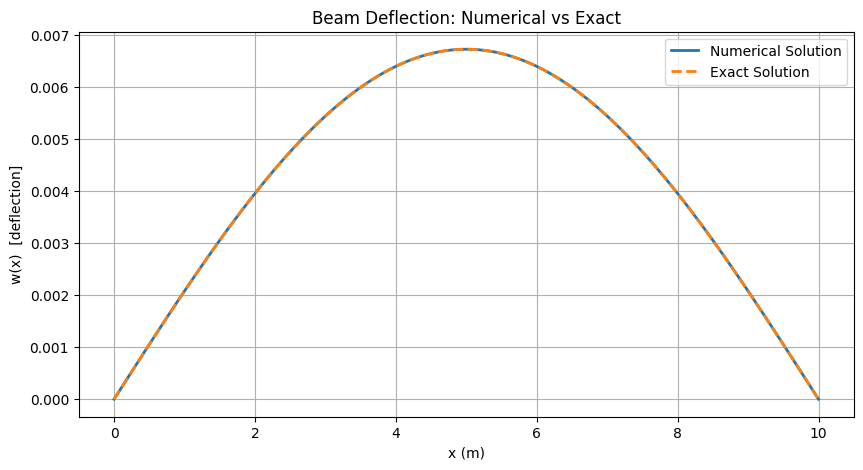

In [19]:
# Comparison of finite difference and exact solution
plt.figure(figsize=(10,5))

plt.plot(x, w, label='Numerical Solution', linewidth=2)
plt.plot(x, w_exact, '--', label='Exact Solution', linewidth=2)

plt.xlabel("x (m)")
plt.ylabel("w(x)  [deflection]")
plt.title("Beam Deflection: Numerical vs Exact")

plt.legend()
plt.grid(True)

plt.show()

## Executive summary

In [21]:
print(f"Computation Time (FD): {end_fd - start_fd:.4f} seconds")
print(f"Computation Time (Exact): {end_exact - start_exact:.4f} seconds")

Computation Time (FD): 0.2354 seconds
Computation Time (Exact): 0.0000 seconds
